# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muchlis Ar Wicaksana
- **Email:** cdcc009d6y2743@student.devacademy.id
- **ID Dicoding:** cdcc009d6y2743

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penjualan dalam beberapa bulan terakhir?
- Bagaimana pengaruh lama waktu pengiriman barang terhadap review score pelanggan?
- Bagaimana pola aktivitas transaksi pelanggan berdasarkan hari dan jam pembelian?
- Bagaimana kecenderungan pelanggan dalam menggunakan fitur installments berdasarkan kategori nominal belanja mereka?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Load Dataset
orders_df = pd.read_csv('olist_orders_dataset.csv')
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
reviews_df = pd.read_csv('olist_order_reviews_dataset.csv')
customers_df = pd.read_csv('olist_customers_dataset.csv')
geo_df = pd.read_csv('olist_geolocation_dataset.csv')

In [3]:
# Menggabungkan dataset utama
orders_customers = pd.merge(orders_df, customers_df, on='customer_id', how='inner')
orders_customers_payments = pd.merge(orders_customers, payments_df, on='order_id', how='inner')
all_df = pd.merge(orders_customers_payments, reviews_df, on='order_id', how='inner')

all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


**Insight:**
- Proses pengumpulan dan load data melliputi 5 tabel utama yaitu `orders`, `payments`, `reviews`, `customers`, dan `geolocation`
- Selain tabel geolocation di gabungkan (merge) mengunakan berdasarkan primary key seperti `order_id` dan `customer_id` untuk mendapatkan tabel `all_df` yang siap untuk dianalisis

### Assessing Data

In [4]:
# Cek Dataset Gabungan
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103677 entries, 0 to 103676
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       103677 non-null  object 
 1   customer_id                    103677 non-null  object 
 2   order_status                   103677 non-null  object 
 3   order_purchase_timestamp       103677 non-null  object 
 4   order_approved_at              103506 non-null  object 
 5   order_delivered_carrier_date   101816 non-null  object 
 6   order_delivered_customer_date  100647 non-null  object 
 7   order_estimated_delivery_date  103677 non-null  object 
 8   customer_unique_id             103677 non-null  object 
 9   customer_zip_code_prefix       103677 non-null  int64  
 10  customer_city                  103677 non-null  object 
 11  customer_state                 103677 non-null  object 
 12  payment_sequential            

In [5]:
# Cek missing Values
all_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,171
order_delivered_carrier_date,1861
order_delivered_customer_date,3030
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [6]:
# Cek Duplikasi Data
all_df.duplicated().sum()

np.int64(0)

**Insight:**
- Terdapat tipe data yang tidak sesuai, yaitu pada kolom tanggal/waktu yang masih berupa object
- Tedapat missing value pada kolom waktu pengiriman contohnya `order_delivered_customer_date`, yang wajar jika pesanan tersebut dibatalkan atau masih dalam proses. Terdapat juga missing value pada `review_comment_title` dan `review_comment_message` yang sebenarnya tidak terlalu berpengaruh karena tidak menjadi indikator analisi kali ini
- Tidak ada data duplikat yang bisa mengganggu proses analisis nantinya

### Cleaning Data

In [7]:
# Memperbaiki tipe data tanggal/waktu
date_time_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_time_cols:
    all_df[col] = pd.to_datetime(all_df[col])
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103677 entries, 0 to 103676
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103677 non-null  object        
 1   customer_id                    103677 non-null  object        
 2   order_status                   103677 non-null  object        
 3   order_purchase_timestamp       103677 non-null  datetime64[ns]
 4   order_approved_at              103506 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101816 non-null  datetime64[ns]
 6   order_delivered_customer_date  100647 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103677 non-null  datetime64[ns]
 8   customer_unique_id             103677 non-null  object        
 9   customer_zip_code_prefix       103677 non-null  int64         
 10  customer_city                  103677 non-null  object        
 11  

In [8]:
# Menangani Missing value (hanya mengambil order yang statusnya delivered)
all_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# Menghapus kolom review selain review id dan review score
all_df.drop(columns=['review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'], inplace=True)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100647 entries, 0 to 103676
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100647 non-null  object        
 1   customer_id                    100647 non-null  object        
 2   order_status                   100647 non-null  object        
 3   order_purchase_timestamp       100647 non-null  datetime64[ns]
 4   order_approved_at              100633 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100646 non-null  datetime64[ns]
 6   order_delivered_customer_date  100647 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100647 non-null  datetime64[ns]
 8   customer_unique_id             100647 non-null  object        
 9   customer_zip_code_prefix       100647 non-null  int64         
 10  customer_city                  100647 non-null  object        
 11  custo

In [9]:
# Feature : Membuat kolom baru untuk memudahkan EDA
all_df['delivery_time_days'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days
all_df['purchase_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
all_df['purchase_day'] = all_df['order_purchase_timestamp'].dt.day_name()
all_df['purchase_hour'] = all_df['order_purchase_timestamp'].dt.hour

all_df.info()
all_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 100647 entries, 0 to 103676
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100647 non-null  object        
 1   customer_id                    100647 non-null  object        
 2   order_status                   100647 non-null  object        
 3   order_purchase_timestamp       100647 non-null  datetime64[ns]
 4   order_approved_at              100633 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100646 non-null  datetime64[ns]
 6   order_delivered_customer_date  100647 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100647 non-null  datetime64[ns]
 8   customer_unique_id             100647 non-null  object        
 9   customer_zip_code_prefix       100647 non-null  int64         
 10  customer_city                  100647 non-null  object        
 11  custo

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,delivery_time_days,purchase_month,purchase_day,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,8,2017-10,Monday,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,8,2017-10,Monday,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,8,2017-10,Monday,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,13,2018-07,Tuesday,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,9,2018-08,Wednesday,8


**Insight:**
- Tipe data tanggal diubah menjadi datetime agar bisa diekstraksi nilai hari, jam, dan bulannya
- Data di filter hanya untuk pesanan yang berhasil terikirim (delivered) untuk menjaga validitas analisis lama waktu pengiriman
- menghapus beberapa kolom seperti `review_comment_title`, `review_comment_message`, `review_creation_date`, `review_answer_timestamp` karena tidak terpakai untuk analisis agar penggunaan memori lebih sedikit juga
- Menambahkan kolom baru `delivery_time_days`, `purchase_month`, `purchase_day`, dan `purchase_hour`

## Exploratory Data Analysis (EDA)

### Explore ...

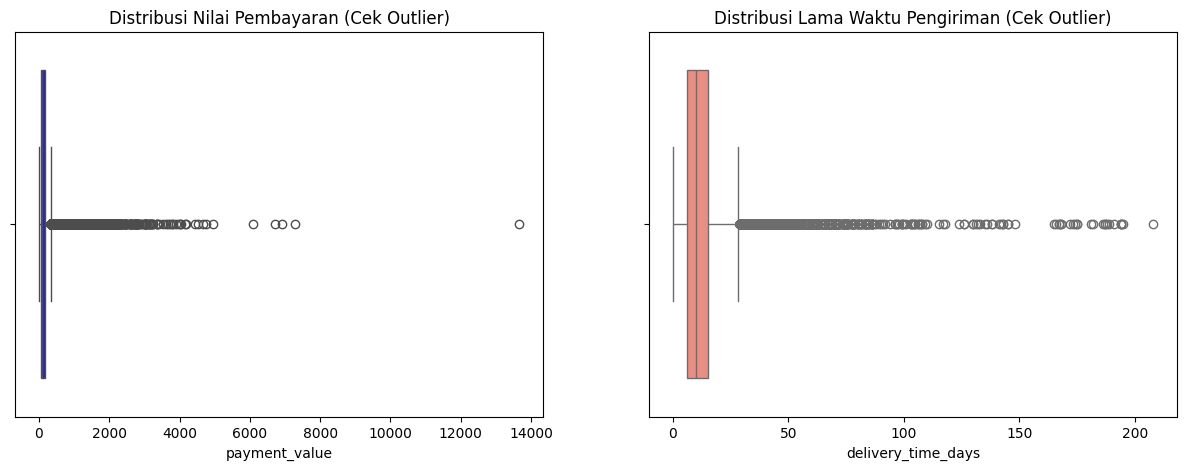

In [11]:
# Cek distribusi dan outlier menggunakan boxplot
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(x=all_df['payment_value'], ax=ax[0], color='blue')
ax[0].set_title('Distribusi Nilai Pembayaran (Cek Outlier)')

sns.boxplot(x=all_df['delivery_time_days'], ax=ax[1], color='salmon')
ax[1].set_title('Distribusi Lama Waktu Pengiriman (Cek Outlier)')
plt.show()

In [12]:
# Agregasi Performa Penjualan
monthly_sales_df = all_df.groupby('purchase_month').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index().rename(columns={
    'order_id': 'total_orders',
    'payment_value': 'total_revenue'
})
monthly_sales_df

,purchase_month,total_orders,total_revenue
0,2016-10,267,46632.06
1,2016-12,1,19.62
2,2017-01,741,127220.28
3,2017-02,1643,271300.41
4,2017-03,2527,409931.88
5,2017-04,2290,388895.58
6,2017-05,3517,565922.66
7,2017-06,3111,491279.56
8,2017-07,3842,564843.08
9,2017-08,4165,644517.15


In [16]:
# Agregasi hubungan pengiriman dengan review score
delivery_review_df = all_df.groupby('review_score').agg({
    'delivery_time_days': 'mean'
}).reset_index()
delivery_review_df

,review_score,delivery_time_days
0,1,20.796041
1,2,16.275784
2,3,13.764522
3,4,11.871372
4,5,10.236879


In [18]:
# Agregasi Hari dan Jam transaksi pelanggan
day_hour_df = all_df.groupby(['purchase_day', 'purchase_hour']).agg({
    'order_id': 'nunique'
}).reset_index()
day_hour_df

,purchase_day,purchase_hour,order_id
0,Friday,0,407
1,Friday,1,209
2,Friday,2,65
3,Friday,3,46
4,Friday,4,38
...,...,...,...
163,Wednesday,19,815
164,Wednesday,20,872
165,Wednesday,21,918
166,Wednesday,22,847


In [19]:
# Clusterin (Binning) Kategori Belanja
# Membagi pelanggan menjadi 3 kategori berdasarkan kuartil payment_value
all_df['payment_category'] = pd.qcut(all_df['payment_value'], q=3, labels=['Low', 'Medium', 'High'])

installment_trend_df = all_df.groupby('payment_category', observed=True).agg({
    'payment_installments': 'mean'
}).reset_index()
installment_trend_df

,payment_category,payment_installments
0,Low,1.660477
1,Medium,2.723633
2,High,4.173572


**Insight:**
- Berdasarkan boxplot, sebaran data pembayaran dan waktu pengiriman sangat condong ke kanan, menunjukkan banyak transaksi bernilai kecil namun terdapat outlier pada nilai transaksi besar dan pengiriman sangat lambat
- Hasil agregasi menunjukan adanya variasi pengeluaran antar bulan
- Tabel pengiriman dengan review score menampilkan tren bahwa nilai bintang rendah berhubungan dengan rata-rata waktu pengiriman yang lebih lama
- Clustering secara binning membagi pengguna kedalam kategori `Low`, `Medium`, `High`, sudah siap divisualisasikan untuk melihat tren installment (cicilan)

## Visualization & Explanatory Analysis

### Pertanyaan 1:

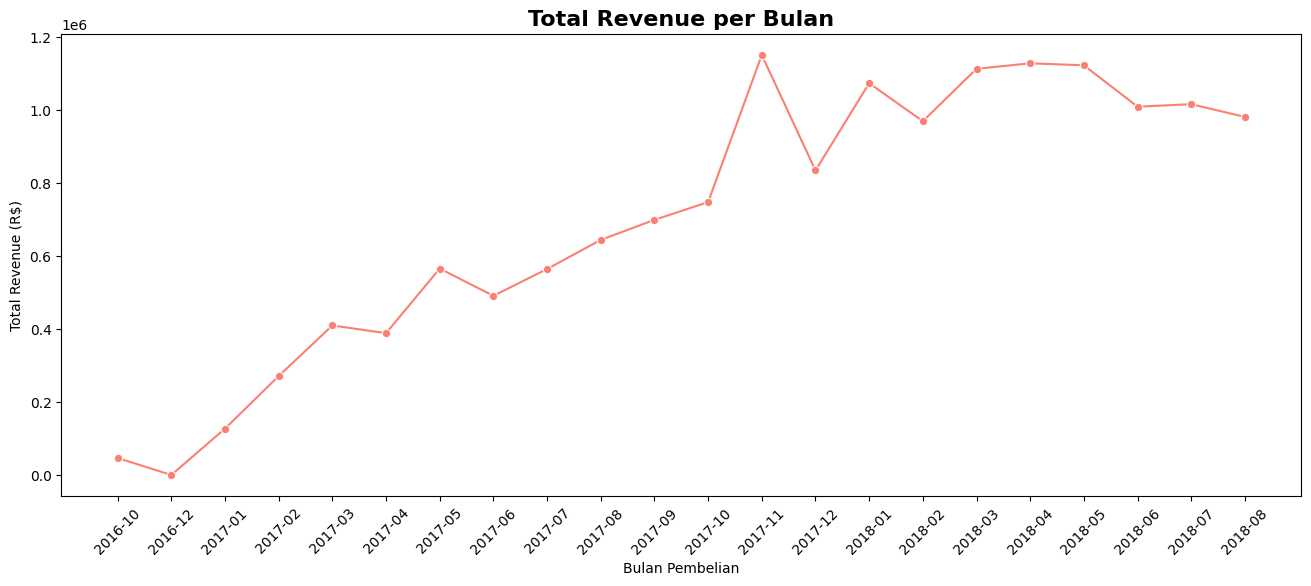

In [20]:
# Bagaimana performa penjualan dan revenue dalam beberapa bulan terakhir
plt.figure(figsize=(16, 6))
sns.lineplot(
    x='purchase_month',
    y='total_revenue',
    data=monthly_sales_df,
    marker='o',
    color='salmon',
)
plt.title('Total Revenue per Bulan', fontsize=16, fontweight='bold')
plt.xlabel('Bulan Pembelian')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_3733/1841809310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


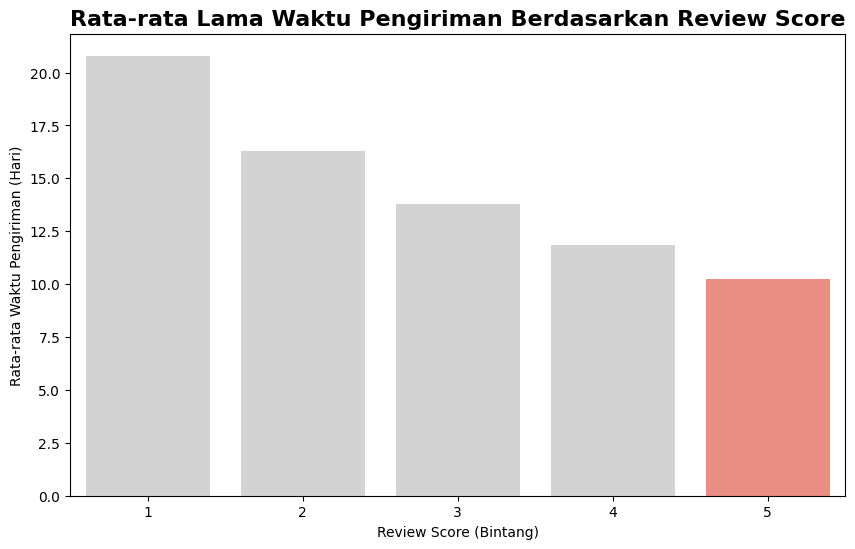

In [29]:
# Bagaimana pengaruh lama waktu pengiriman terhadap review score
plt.figure(figsize=(10, 6))
sns.barplot(
    x='review_score',
    y='delivery_time_days',
    data=delivery_review_df,
    palette=['#D3D3D3', '#D3D3D3', '#D3D3D3', '#D3D3D3', 'salmon']
)
plt.title('Rata-rata Lama Waktu Pengiriman Berdasarkan Review Score', fontsize=16, fontweight='bold')
plt.xlabel('Review Score (Bintang)')
plt.ylabel('Rata-rata Waktu Pengiriman (Hari)')
plt.show()

### Pertanyaan 3:

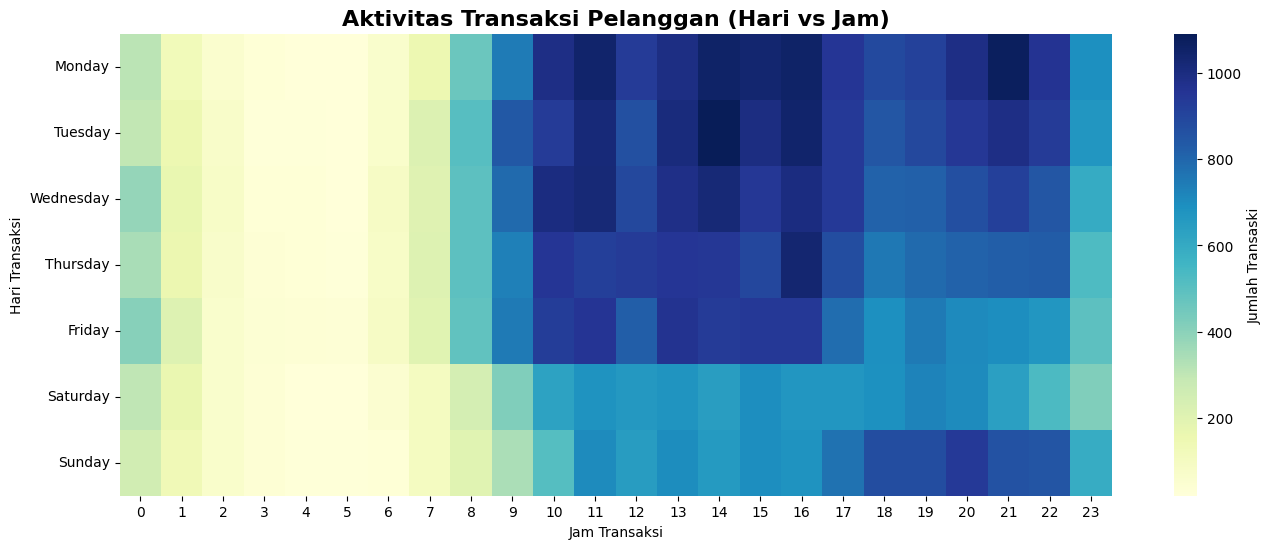

In [26]:
# Bagaimana pola aktivitas transaksi pelanggan berdasarkan hari dan jam
heatmap_data = day_hour_df.pivot(index='purchase_day', columns='purchase_hour', values='order_id').fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    cbar_kws={'label': 'Jumlah Transaski'}
)
plt.title('Aktivitas Transaksi Pelanggan (Hari vs Jam)', fontsize=16, fontweight='bold')
plt.xlabel('Jam Transaksi')
plt.ylabel('Hari Transaksi')
plt.show()

### Pertanyaan 4:

/tmp/ipykernel_3733/1388028969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


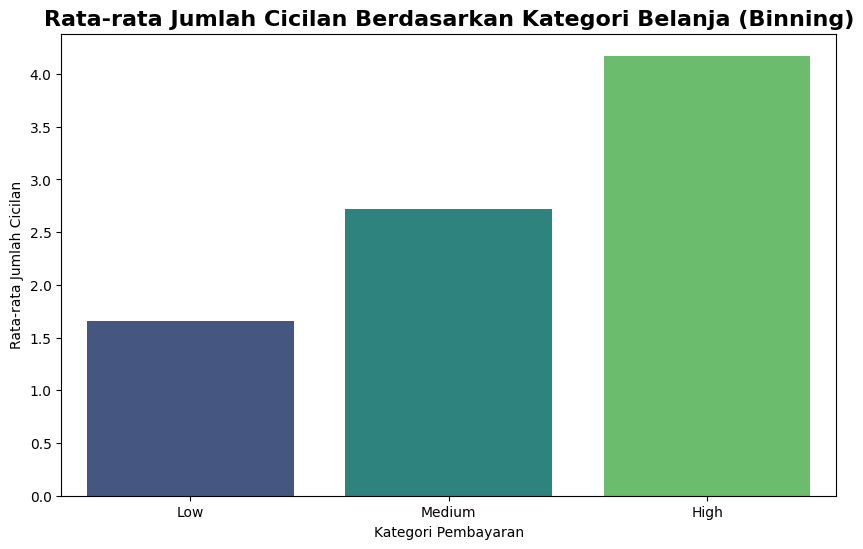

In [28]:
# Bagaimana kecenderungan penggunaan installment (cicilan) berdasarkan kategori nominal belanja
plt.figure(figsize=(10, 6))
sns.barplot(
    x='payment_category',
    y='payment_installments',
    data=installment_trend_df,
    palette='viridis'
)
plt.title('Rata-rata Jumlah Cicilan Berdasarkan Kategori Belanja (Binning)', fontsize=16, fontweight='bold')
plt.xlabel('Kategori Pembayaran')
plt.ylabel('Rata-rata Jumlah Cicilan')
plt.show()

**Insight:**
- Terdapat peningkatan pesat revenue hingga titik tertinggi di bulan November 2017, dan performa tersebut relatif stabil sepanjang tahun 2018.
- Pelanggan yang memberikan rating buruk (bintang 1) rata-rata mengalami pengiriman barang diatas 20 hari
- Pola aktivitas belanja banyak pada siang hari pada pukul (10:00 - 16:00) pada hari kerja yaitu Senin - Jumat
- Pelanggan pada kategori belanja `High` secara signifikan memiliki rata-rata jumlah cicilan yang jauh lebih banyak

## Analisis Lanjutan (Opsional)

In [33]:
# RFM Analysis
recent_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm_df = all_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'payment_value': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']
rfm_df.head()

,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


/tmp/ipykernel_3733/807251590.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


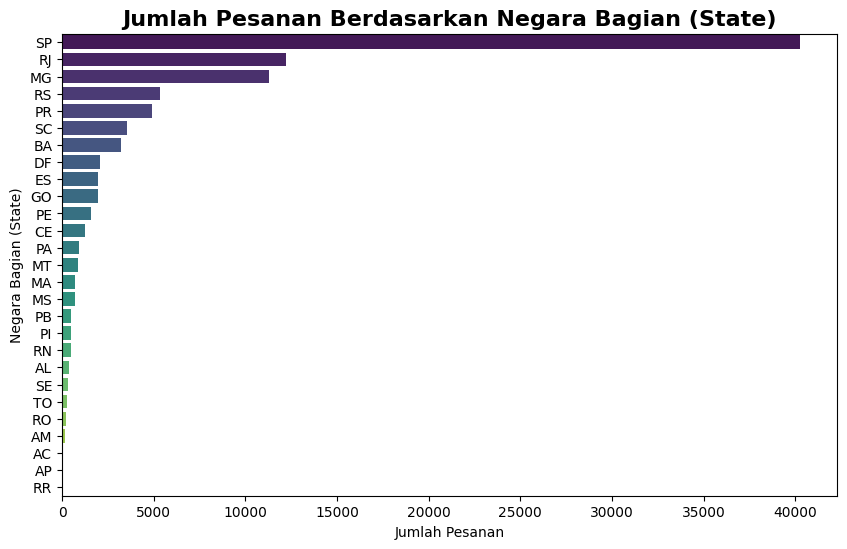

In [40]:
# Geospatial Analysis

# Menghitung jumlah pesanan berdasarkan negara bagian (customer_state)
state_orders_df = all_df.groupby('customer_state').order_id.nunique().reset_index()
state_orders_df.rename(columns={
    'order_id': 'total_orders'
}, inplace=True)

# Mengurutkan data dari jumlah pesanan terbanyak
state_orders_df = state_orders_df.sort_values(by='total_orders', ascending=False)

# Visual
plt.figure(figsize=(10, 6))
sns.barplot(
    x='total_orders',
    y='customer_state',
    data=state_orders_df,
    palette='viridis'
)
plt.title('Jumlah Pesanan Berdasarkan Negara Bagian (State)', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Pesanan')
plt.ylabel('Negara Bagian (State)')
plt.show()

In [41]:
all_df.to_csv('all_df.csv', index=False)

## Conclusion

- Conclution pertanyaan 1: Performa penjualan secara keseluruhan mengalami pertumbuhan yang positif, dengan revenue tertinggi terjadi pada sati titik tertentu (misalnya bulan November) yang dapat dijadikan acuan strategi promosi tahun depan.
- Conclution pertanyaan 2: Waktu pengiriman adalah faktor penting yang menentukan review score. Pelanggan memberikan rating buruk ketika paket memakan waktu rata-rata 20 hari untuk tiba. Batas aman untuk pengiriman agar customer puas adalah dibawah 10-14 hari
- Conclution pertanyaan 3: Mayoritas aktivitas transaksi berpusat pada hari kerja (senin - jumat) di jam 10.00 hingga 16.00, serta malam hari sekitar pukul 20.00 - 22.00. Ini menandakan customer cenderung belanja di sela-sela aktivitas mereka, sehingga operasional iklan atau pemasaran dapat dioptimalkan pada jam tersebut.
- Conclution pertanyaan 4: Teknik Clustering menggunakn Binning membuktikan bahwa pelanggan sangat bergantung pada penggunaan fasilitas installment (cicilan) ketika membeli barang dengan kategori nominal tinggi.
- Conclution Analisis Lanjutan: Melalui RFM Analysis, bisnis dapat memetakan siapa top spender yang harus dirawat loyalitasnya. Sementara itu visualisasi Geospatial Analysis menunjukan perbandingan pelanggan yang tajamm, mayoritas pelanggan berada di negara bagian SP (Sao Paulo). Hal ini menandakan bahwa fokus utama logistik dan distribusi harus di prioritaskan di wilayah SP